# DE gene summary

Extracts differentially expressed genes (10% FDR) from `GWCD4i.DE_stats.h5ad` for PTPN11, PTPN6, PDCD1, BTLA across all three conditions.

### 1. Extract DE genes and save CSVs

In [1]:
import anndata
import numpy as np
import pandas as pd
import scipy.sparse
import os

DESTATS_PATH = '../Data/GWCD4i.DE_stats.h5ad'
OUT_DIR = '../Results/diagnostics/'
os.makedirs(OUT_DIR, exist_ok=True)

GENES_OF_INTEREST = ['PTPN11', 'PTPN6', 'PDCD1', 'BTLA']
CONDITIONS = ['Rest', 'Stim8hr', 'Stim48hr']
P_THRESHOLD = 0.10 # adjusted p-value / FDR threshold

de_stats = anndata.read_h5ad(DESTATS_PATH, backed='r')
gene_names = de_stats.var_names.values
obs = de_stats.obs.copy()

# Build Ensembl -> symbol map from var if available
var_df = de_stats.var.copy()
symbol_col = next((c for c in ['gene_name', 'symbol', 'gene_symbol', 'feature_name'] if c in var_df.columns), None)
if symbol_col:
    ensembl_to_symbol = dict(zip(var_df.index, var_df[symbol_col]))
    print(f'Symbol map built from var["{symbol_col}"]: {len(ensembl_to_symbol)} entries')
else:
    ensembl_to_symbol = {}
    print(f'No symbol column in var (columns: {var_df.columns.tolist()}). Using Ensembl IDs as fallback.')

results = {}
for gene in GENES_OF_INTEREST:
    results[gene] = {}
    for cond in CONDITIONS:
        mask = (obs['target_contrast_gene_name'] == gene) & (obs['culture_condition'] == cond)
        if mask.sum() == 0:
            print(f'{gene} | {cond}: not found in DE_stats')
            results[gene][cond] = None
            continue

        slice_de = de_stats[mask]
        adj_p = slice_de.layers['adj_p_value']
        log_fc = slice_de.layers['log_fc']
        if scipy.sparse.issparse(adj_p):
            adj_p = adj_p.toarray()
            log_fc = log_fc.toarray()
        adj_p = np.asarray(adj_p, dtype=np.float32).squeeze()
        log_fc = np.asarray(log_fc, dtype=np.float32).squeeze()

        sig_mask = (adj_p <= P_THRESHOLD) & (~np.isnan(adj_p))
        sig_ensembl = gene_names[sig_mask]
        sig_symbols = [ensembl_to_symbol.get(e, e) for e in sig_ensembl]
        sig_lfc = log_fc[sig_mask]
        sig_padj = adj_p[sig_mask]

        df_out = pd.DataFrame({
            'ensembl_id': sig_ensembl,
            'gene_symbol': sig_symbols,
            'log_fc': sig_lfc,
            'adj_p_value': sig_padj
        }).sort_values('adj_p_value')

        results[gene][cond] = df_out
        fname = os.path.join(OUT_DIR, f'DE_genes_{gene}_{cond}.csv')
        df_out.to_csv(fname, index=False)
        print(f'{gene} | {cond}: {len(df_out)} DE genes saved to {fname}')

de_stats.file.close()

Symbol map built from var["gene_name"]: 10282 entries
PTPN11 | Rest: 8 DE genes saved to ../Results/diagnostics/DE_genes_PTPN11_Rest.csv
PTPN11 | Stim8hr: 4 DE genes saved to ../Results/diagnostics/DE_genes_PTPN11_Stim8hr.csv
PTPN11 | Stim48hr: 60 DE genes saved to ../Results/diagnostics/DE_genes_PTPN11_Stim48hr.csv
PTPN6 | Rest: 19 DE genes saved to ../Results/diagnostics/DE_genes_PTPN6_Rest.csv
PTPN6 | Stim8hr: 2 DE genes saved to ../Results/diagnostics/DE_genes_PTPN6_Stim8hr.csv
PTPN6 | Stim48hr: 4 DE genes saved to ../Results/diagnostics/DE_genes_PTPN6_Stim48hr.csv
PDCD1 | Rest: 0 DE genes saved to ../Results/diagnostics/DE_genes_PDCD1_Rest.csv
PDCD1 | Stim8hr: 1 DE genes saved to ../Results/diagnostics/DE_genes_PDCD1_Stim8hr.csv
PDCD1 | Stim48hr: 2 DE genes saved to ../Results/diagnostics/DE_genes_PDCD1_Stim48hr.csv
BTLA | Rest: 10 DE genes saved to ../Results/diagnostics/DE_genes_BTLA_Rest.csv
BTLA | Stim8hr: 1 DE genes saved to ../Results/diagnostics/DE_genes_BTLA_Stim8hr.csv
BT

### 2. Summary count table

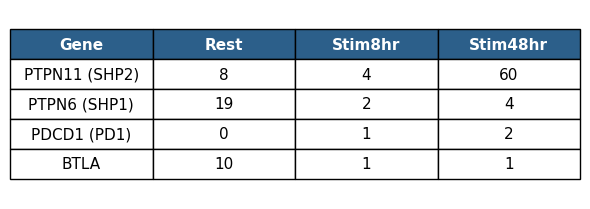

Saved: ../Results/diagnostics/DE_summary_table.png


In [2]:
import matplotlib.pyplot as plt

gene_labels = ['PTPN11 (SHP2)', 'PTPN6 (SHP1)', 'PDCD1 (PD1)', 'BTLA']
table_data = [
    [g_label] + [str(len(results[g][c])) if results[g].get(c) is not None else '0'
                 for c in CONDITIONS]
    for g, g_label in zip(GENES_OF_INTEREST, gene_labels)]
col_labels = ['Gene'] + CONDITIONS

fig, ax = plt.subplots(figsize=(6, 2.2))
ax.axis('off')

table = ax.table(
    cellText=table_data,
    colLabels=col_labels,
    loc='center',
    cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 1.6)

for j in range(len(col_labels)):
    table[0, j].set_facecolor('#2c5f8a')
    table[0, j].set_text_props(color='white', fontweight='bold')

for i in range(1, len(GENES_OF_INTEREST)+1):
    for j in range(len(col_labels)):
        table[i, j].set_facecolor('white')
        if j > 0:
            val = int(table_data[i-1][j])

plt.tight_layout()
fname = os.path.join(OUT_DIR, 'DE_summary_table.png')
plt.savefig(fname, dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved: {fname}')

### 3. Footprint bar chart + Jaccard heatmap

Builds `pooled_sets` (used also in cells 4 and 5).

Pairwise Jaccard similarities (pooled):
  PTPN11 vs PTPN6: 0.000 (0 shared genes)
  PTPN11 vs PDCD1: 0.000 (0 shared genes)
  PTPN11 vs BTLA: 0.000 (0 shared genes)
  PTPN6 vs PDCD1: 0.000 (0 shared genes)
  PTPN6 vs BTLA: 0.000 (0 shared genes)
  PDCD1 vs BTLA: 0.000 (0 shared genes)


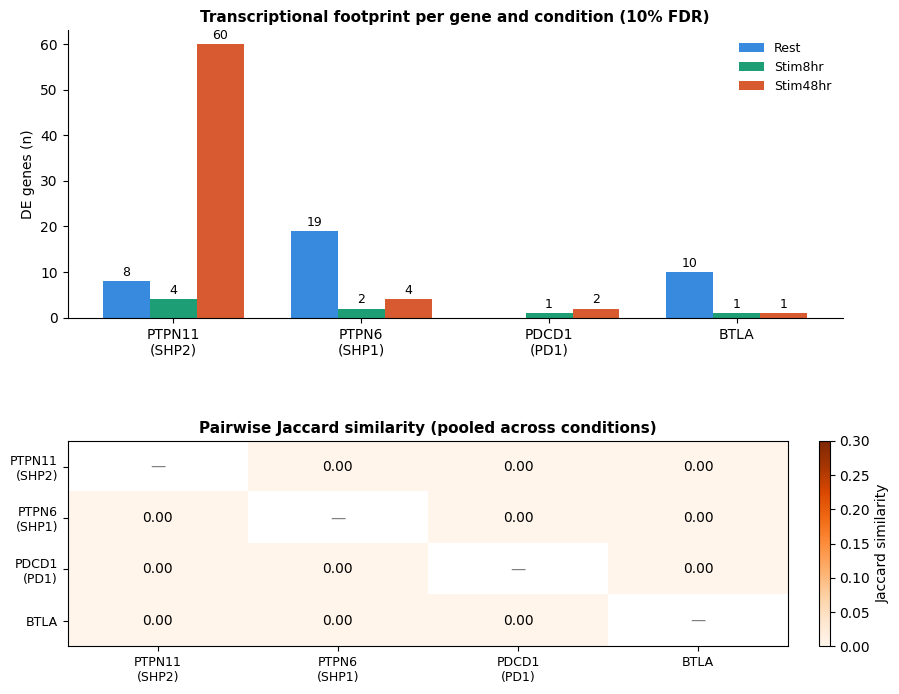

Saved: ../Results/diagnostics/DE_footprint_summary.png


In [3]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from itertools import combinations

GENE_LABELS = ['PTPN11\n(SHP2)', 'PTPN6\n(SHP1)', 'PDCD1\n(PD1)', 'BTLA']

counts = {
    g: [len(results[g][c]) if results[g].get(c) is not None else 0 for c in CONDITIONS]
    for g in GENES_OF_INTEREST
}

# Pooled DE gene sets (gene_symbol) — reused in cells 4 and 5
pooled_sets = {}
for g in GENES_OF_INTEREST:
    s = set()
    for c in CONDITIONS:
        df = results[g].get(c)
        if df is not None and len(df) > 0:
            s.update(df['gene_symbol'].tolist())
    pooled_sets[g] = s

n = len(GENES_OF_INTEREST)
jaccard_matrix = np.zeros((n, n))
for i, g1 in enumerate(GENES_OF_INTEREST):
    for j, g2 in enumerate(GENES_OF_INTEREST):
        if i == j:
            jaccard_matrix[i, j] = np.nan
        else:
            inter = len(pooled_sets[g1] & pooled_sets[g2])
            union = len(pooled_sets[g1] | pooled_sets[g2])
            jaccard_matrix[i, j] = inter / union if union > 0 else 0.0

print('Pairwise Jaccard similarities (pooled):')
for i, j in combinations(range(n), 2):
    g1, g2 = GENES_OF_INTEREST[i], GENES_OF_INTEREST[j]
    print(f'  {g1} vs {g2}: {jaccard_matrix[i,j]:.3f} ({len(pooled_sets[g1] & pooled_sets[g2])} shared genes)')

colors = ['#378ADD', '#1D9E75', '#D85A30']
x = np.arange(n)
width = 0.25

fig = plt.figure(figsize=(10, 8))
gs = gridspec.GridSpec(2, 1, figure=fig, height_ratios=[1.4, 1], hspace=0.5)

ax1 = fig.add_subplot(gs[0])
for ci, (cond, color) in enumerate(zip(CONDITIONS, colors)):
    vals = [counts[g][ci] for g in GENES_OF_INTEREST]
    bars = ax1.bar(x + ci*width, vals, width, label=cond, color=color)
    for bar, val in zip(bars, vals):
        if val > 0:
            ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                     str(val), ha='center', va='bottom', fontsize=9)

ax1.set_xticks(x + width)
ax1.set_xticklabels(GENE_LABELS, fontsize=10)
ax1.set_ylabel('DE genes (n)', fontsize=10)
ax1.set_title('Transcriptional footprint per gene and condition (10% FDR)', fontsize=11, fontweight='bold')
ax1.legend(frameon=False, fontsize=9)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

ax2 = fig.add_subplot(gs[1])
masked = np.ma.masked_invalid(jaccard_matrix)
im = ax2.imshow(masked, cmap='Oranges', vmin=0, vmax=0.3, aspect='auto')
ax2.set_xticks(range(n))
ax2.set_yticks(range(n))
ax2.set_xticklabels(GENE_LABELS, fontsize=9)
ax2.set_yticklabels(GENE_LABELS, fontsize=9)
ax2.set_title('Pairwise Jaccard similarity (pooled across conditions)', fontsize=11, fontweight='bold')

for i in range(n):
    for j in range(n):
        if i == j:
            ax2.text(j, i, '—', ha='center', va='center', fontsize=11, color='gray')
        else:
            val = jaccard_matrix[i, j]
            ax2.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=10,
                     fontweight='bold' if val > 0.05 else 'normal',
                     color='white' if val > 0.2 else 'black')

plt.colorbar(im, ax=ax2, fraction=0.03, pad=0.04, label='Jaccard similarity')

fname = os.path.join(OUT_DIR, 'DE_footprint_summary.png')
plt.savefig(fname, dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved: {fname}')

### 4. Pairwise Venn diagrams

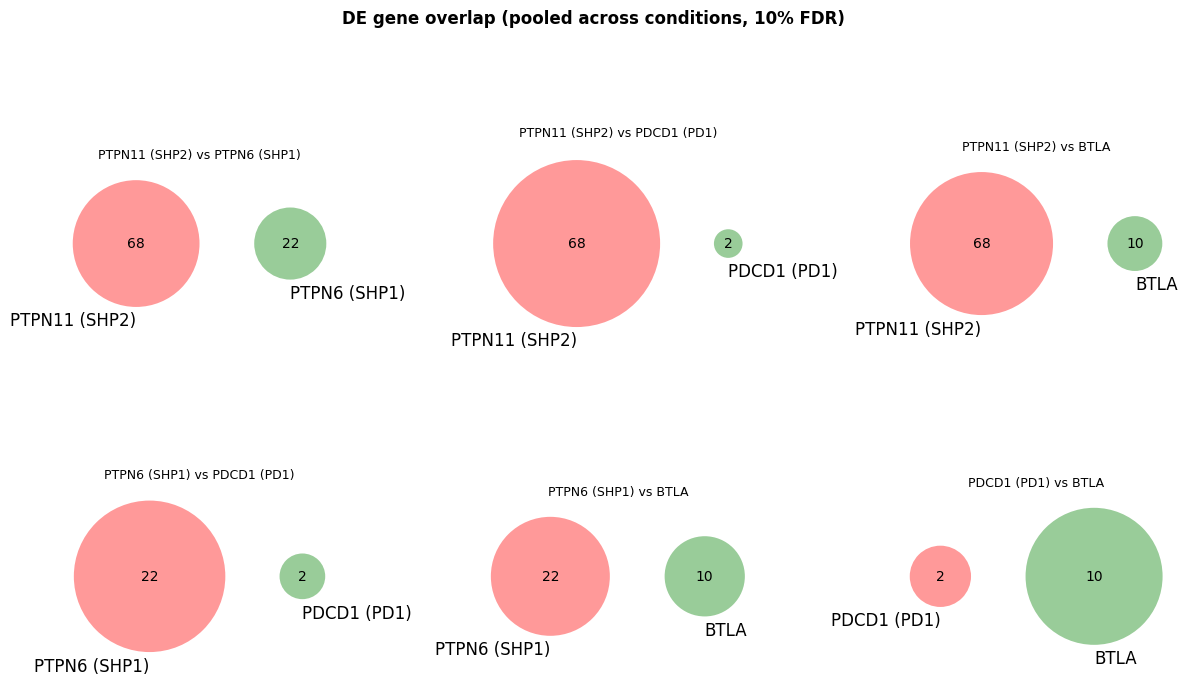

Saved: ../Results/diagnostics/venn_pairwise_DE_overlap.png


In [4]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn2
from itertools import combinations

pair_labels = {'PTPN11': 'PTPN11 (SHP2)',
    'PTPN6': 'PTPN6 (SHP1)',
    'PDCD1': 'PDCD1 (PD1)',
    'BTLA': 'BTLA'}

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
fig.suptitle('DE gene overlap (pooled across conditions, 10% FDR)', fontsize=12, fontweight='bold')

pairs = list(combinations(GENES_OF_INTEREST, 2))
for ax, (g1, g2) in zip(axes.flat, pairs):
    venn2([pooled_sets[g1], pooled_sets[g2]],
          set_labels=(pair_labels[g1], pair_labels[g2]),
          ax=ax)
    ax.set_title(f'{pair_labels[g1]} vs {pair_labels[g2]}', fontsize=9)

axes.flat[-1].axis('off')

plt.tight_layout()
fname = os.path.join(OUT_DIR, 'venn_pairwise_DE_overlap.png')
plt.savefig(fname, dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved: {fname}')

### 5. Proportional circle plot

Circle area proportional to number of unique DE genes. Circles are non-overlapping to reflect Jaccard = 0 for all pairs.

/tmp/ipykernel_537568/1493194782.py:16: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  circle = plt.Circle(cfg['pos'], r, color=cfg['color'], alpha=0.5,


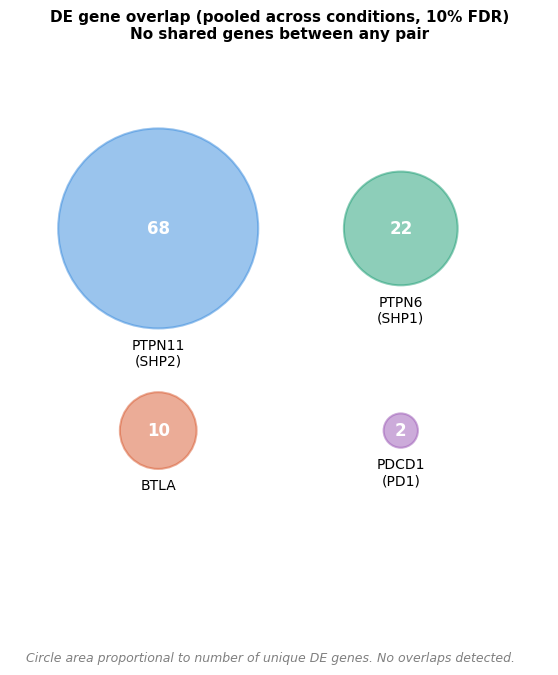

Saved: ../Results/diagnostics/venn4_DE_overlap.png


In [5]:
import matplotlib.pyplot as plt
import numpy as np

gene_plot_config = {
    'PTPN11': {'label': 'PTPN11\n(SHP2)', 'pos': (-1.8, 1.5), 'color': '#378ADD'},
    'PTPN6': {'label': 'PTPN6\n(SHP1)', 'pos': (1.8, 1.5), 'color': '#1D9E75'},
    'BTLA': {'label': 'BTLA', 'pos': (-1.8, -1.5), 'color': '#D85A30'},
    'PDCD1': {'label': 'PDCD1\n(PD1)', 'pos': (1.8, -1.5), 'color': '#9B59B6'}}

scale = 0.18
fig, ax = plt.subplots(figsize=(7, 7))

for g, cfg in gene_plot_config.items():
    n_genes = len(pooled_sets[g])
    r = np.sqrt(n_genes) * scale
    circle = plt.Circle(cfg['pos'], r, color=cfg['color'], alpha=0.5,
                        linewidth=1.5, edgecolor=cfg['color'])
    ax.add_patch(circle)
    ax.text(cfg['pos'][0], cfg['pos'][1], str(n_genes),
            ha='center', va='center', fontsize=12, fontweight='bold', color='white')
    ax.text(cfg['pos'][0], cfg['pos'][1] - r - 0.15, cfg['label'],
            ha='center', va='top', fontsize=10)

ax.set_xlim(-4, 4)
ax.set_ylim(-4, 4)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('DE gene overlap (pooled across conditions, 10% FDR)\nNo shared genes between any pair',
             fontsize=11, fontweight='bold', pad=15)
fig.text(0.5, 0.02, 'Circle area proportional to number of unique DE genes. No overlaps detected.',
         ha='center', fontsize=9, color='gray', style='italic')

fname = os.path.join(OUT_DIR, 'venn4_DE_overlap.png')
plt.savefig(fname, dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved: {fname}')

---
## 6. DPD score profiling across conditions

Loads `DPD_ranked_filtered_{run_tag}.csv` for Rest, Stim8hr, and Stim48hr and extracts scores for the four checkpoint genes.

**Biological expectations**
- **PTPN11 (SHP2)**: phosphatase downstream of activating receptors; knockdown expected to suppress activation → negative DPD_stim, especially post-stimulation.
- **PTPN6 (SHP1)**: dampens TCR signalling at rest; knockdown expected to enhance activation at Rest, effect may attenuate post-stimulation.
- **PDCD1 (PD-1)**: requires ligand (PD-L1/L2), absent in vitro → minimal transcriptional footprint and near-zero DPD expected in all conditions.
- **BTLA**: inhibitory receptor active at rest; knockdown expected to show negative DPD_stim at Rest (disinhibition), attenuating post-stimulation.

**Score definitions**
- `DPD_stim` (raw): dot product of perturbation log-FC vector with v_stim. Sensitive to footprint size.
- `DPD_stim_norm`: DPD_stim divided by ||v_stim||. Comparable across conditions.
- `DPD_btla` / `DPD_btla_norm`: same, projected onto the BTLA inhibitory axis.
- Rank percentile: position within quality-filtered genes ranked by |DPD_stim_norm| — lower = stronger effect.

### 6.1 Load DPD tables and compute deltas vs Rest

In [6]:
import pandas as pd
import numpy as np
import os

DONORS = ["D1", "D2", "D3", "D4"]
donors_tag = "_".join(DONORS)
RESULTS_BASE = "../Results"
OUT_DIR = "../Results/diagnostics/"
os.makedirs(OUT_DIR, exist_ok=True)

GENES_OF_INTEREST = ["PTPN11", "PTPN6", "PDCD1", "BTLA"]
GENE_LABELS = {"PTPN11": "PTPN11 (SHP2)", "PTPN6": "PTPN6 (SHP1)",
               "PDCD1": "PDCD1 (PD1)", "BTLA": "BTLA"}
ALL_CONDITIONS = ["Rest", "Stim8hr", "Stim48hr"]

records = []
for cond in ALL_CONDITIONS:
    run_tag = f"{cond}_{donors_tag}"
    fpath = os.path.join(RESULTS_BASE, cond, f"DPD_ranked_filtered_{run_tag}.csv")
    if not os.path.exists(fpath):
        print(f"WARNING: {fpath} not found, skipping {cond}")
        continue
    dpd = pd.read_csv(fpath, index_col=0)
    n_total = len(dpd)
    print(f"{cond}: {n_total} genes in ranked table")
    for gene in GENES_OF_INTEREST:
        match = dpd[dpd["target_contrast_gene_name"] == gene]
        if len(match) == 0:
            print(f"  {gene}: not found in {cond}")
            records.append({"gene": gene, "condition": cond, "n_total_ranked": n_total,
                            "rank": None, "rank_pct": None,
                            "DPD_stim": None, "DPD_stim_norm": None,
                            "DPD_btla": None, "DPD_btla_norm": None,
                            "n_sig_genes": None, "n_cells_target": None,
                            "ontarget_significant": None, "offtarget_flag": None})
        else:
            r = match.iloc[0]
            rank = int(match.index[0])
            records.append({
                "gene": gene, "condition": cond, "n_total_ranked": n_total,
                "rank": rank,
                "rank_pct": round(100 * rank / n_total, 1),
                "DPD_stim": round(float(r["DPD_stim"]), 4),
                "DPD_stim_norm": round(float(r["DPD_stim_norm"]), 4),
                "DPD_btla": round(float(r["DPD_btla"]), 4),
                "DPD_btla_norm": round(float(r["DPD_btla_norm"]), 4),
                "n_sig_genes": int(r["n_sig_genes"]),
                "n_cells_target": int(r["n_cells_target"]),
                "ontarget_significant": bool(r["ontarget_significant"]),
                "offtarget_flag": bool(r["offtarget_flag"])})

dpd_long = pd.DataFrame(records)
dpd_long["gene_label"] = dpd_long["gene"].map(GENE_LABELS)
dpd_long["condition"] = pd.Categorical(dpd_long["condition"], categories=ALL_CONDITIONS, ordered=True)
dpd_long = dpd_long.sort_values(["gene", "condition"]).reset_index(drop=True)

rest_stim = dpd_long[dpd_long["condition"]=="Rest"].set_index("gene")["DPD_stim"]
rest_stim_norm = dpd_long[dpd_long["condition"]=="Rest"].set_index("gene")["DPD_stim_norm"]
dpd_long["delta_stim"] = dpd_long.apply(
    lambda row: round(float(row["DPD_stim"]) - float(rest_stim.get(row["gene"], float("nan"))), 4)
    if pd.notna(row["DPD_stim"]) and row["gene"] in rest_stim.index else None, axis=1)
dpd_long["delta_stim_norm"] = dpd_long.apply(
    lambda row: round(float(row["DPD_stim_norm"]) - float(rest_stim_norm.get(row["gene"], float("nan"))), 4)
    if pd.notna(row["DPD_stim_norm"]) and row["gene"] in rest_stim_norm.index else None, axis=1)

fname_csv = os.path.join(OUT_DIR, "DPD_scores_checkpoint_genes_all_conditions.csv")
dpd_long.to_csv(fname_csv, index=False)
print(f"Full table saved: {fname_csv}")
dpd_long

Rest: 6017 genes in ranked table
  PDCD1: not found in Rest
Stim8hr: 6253 genes in ranked table
Stim48hr: 6373 genes in ranked table
Full table saved: ../Results/diagnostics/DPD_scores_checkpoint_genes_all_conditions.csv


,gene,condition,n_total_ranked,rank,rank_pct,DPD_stim,DPD_stim_norm,DPD_btla,DPD_btla_norm,n_sig_genes,n_cells_target,ontarget_significant,offtarget_flag,gene_label,delta_stim,delta_stim_norm
0,BTLA,Rest,6017,2902.0,48.2,0.0000,0.0000,NaN,NaN,5.0,916.0,True,False,BTLA,0.0000,0.0000
1,BTLA,Stim8hr,6253,6014.0,96.2,0.0000,0.0000,0.6497,0.0348,1.0,690.0,True,False,BTLA,0.0000,0.0000
2,BTLA,Stim48hr,6373,5908.0,92.7,0.0000,0.0000,0.0000,0.0000,1.0,720.0,True,False,BTLA,0.0000,0.0000
3,PDCD1,Rest,6017,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,PDCD1 (PD1),NaN,NaN
4,PDCD1,Stim8hr,6253,3445.0,55.1,0.0000,0.0000,0.0000,0.0000,1.0,247.0,True,False,PDCD1 (PD1),NaN,NaN
5,PDCD1,Stim48hr,6373,2136.0,33.5,-0.4272,-0.0212,0.0000,0.0000,1.0,267.0,True,False,PDCD1 (PD1),NaN,NaN
6,PTPN11,Rest,6017,379.0,6.3,1.3709,0.1867,NaN,NaN,8.0,895.0,True,False,PTPN11 (SHP2),0.0000,0.0000
7,PTPN11,Stim8hr,6253,5034.0,80.5,0.0000,0.0000,0.0000,0.0000,2.0,986.0,True,False,PTPN11 (SHP2),-1.3709,-0.1867
8,PTPN11,Stim48hr,6373,3347.0,52.5,-0.0740,-0.0037,0.0000,0.0000,39.0,1019.0,True,False,PTPN11 (SHP2),-1.4449,-0.1904
9,PTPN6,Rest,6017,522.0,8.7,-1.0395,-0.1416,NaN,NaN,11.0,350.0,True,False,PTPN6 (SHP1),0.0000,0.0000


### 6.2 Table: DPD_stim (raw)

In [7]:
# Raw dot product — sensitive to footprint size
pivot = dpd_long.pivot(index="gene_label", columns="condition", values="DPD_stim")
pivot = pivot.reindex([GENE_LABELS[g] for g in GENES_OF_INTEREST])
pivot.index.name = "gene"
print("DPD_stim raw")
display(pivot)
pivot.to_csv(os.path.join(OUT_DIR, "table_DPD_stim.csv"))
print("Saved: table_DPD_stim.csv")

DPD_stim raw


condition,Rest,Stim8hr,Stim48hr
gene,,,
PTPN11 (SHP2),1.3709,0.0000,-0.0740
PTPN6 (SHP1),-1.0395,-1.0573,-1.5099
PDCD1 (PD1),NaN,0.0000,-0.4272
BTLA,0.0000,0.0000,0.0000


Saved: table_DPD_stim.csv


### 6.3 Table: DPD_stim_norm

In [8]:
# Normalised by ||v_stim||
pivot = dpd_long.pivot(index="gene_label", columns="condition", values="DPD_stim_norm")
pivot = pivot.reindex([GENE_LABELS[g] for g in GENES_OF_INTEREST])
pivot.index.name = "gene"
print("DPD_stim_norm")
display(pivot)
pivot.to_csv(os.path.join(OUT_DIR, "table_DPD_stim_norm.csv"))
print("Saved: table_DPD_stim_norm.csv")

DPD_stim_norm


condition,Rest,Stim8hr,Stim48hr
gene,,,
PTPN11 (SHP2),0.1867,0.000,-0.0037
PTPN6 (SHP1),-0.1416,-0.144,-0.0750
PDCD1 (PD1),NaN,0.000,-0.0212
BTLA,0.0000,0.000,0.0000


Saved: table_DPD_stim_norm.csv


### 6.4 Table: DPD_btla (raw)

In [9]:
pivot = dpd_long.pivot(index="gene_label", columns="condition", values="DPD_btla")
pivot = pivot.reindex([GENE_LABELS[g] for g in GENES_OF_INTEREST])
pivot.index.name = "gene"
print("DPD_btla raw")
display(pivot)
pivot.to_csv(os.path.join(OUT_DIR, "table_DPD_btla.csv"))
print("Saved: table_DPD_btla.csv")

DPD_btla raw


condition,Rest,Stim8hr,Stim48hr
gene,,,
PTPN11 (SHP2),NaN,0.0000,0.0
PTPN6 (SHP1),NaN,0.0000,0.0
PDCD1 (PD1),NaN,0.0000,0.0
BTLA,NaN,0.6497,0.0


Saved: table_DPD_btla.csv


### 6.5 Table: DPD_btla_norm

In [10]:
pivot = dpd_long.pivot(index="gene_label", columns="condition", values="DPD_btla_norm")
pivot = pivot.reindex([GENE_LABELS[g] for g in GENES_OF_INTEREST])
pivot.index.name = "gene"
print("DPD_btla_norm")
display(pivot)
pivot.to_csv(os.path.join(OUT_DIR, "table_DPD_btla_norm.csv"))
print("Saved: table_DPD_btla_norm.csv")

DPD_btla_norm


condition,Rest,Stim8hr,Stim48hr
gene,,,
PTPN11 (SHP2),NaN,0.0000,0.0
PTPN6 (SHP1),NaN,0.0000,0.0
PDCD1 (PD1),NaN,0.0000,0.0
BTLA,NaN,0.0348,0.0


Saved: table_DPD_btla_norm.csv


### 6.6 Table: Delta DPD_stim (raw) vs Rest

In [11]:
pivot = dpd_long[dpd_long["condition"] != "Rest"].pivot(
    index="gene_label", columns="condition", values="delta_stim")
pivot = pivot.reindex([GENE_LABELS[g] for g in GENES_OF_INTEREST])
pivot.index.name = "gene"
print("Delta DPD_stim raw vs Rest")
display(pivot)
pivot.to_csv(os.path.join(OUT_DIR, "table_delta_stim.csv"))
print("Saved: table_delta_stim.csv")

Delta DPD_stim raw vs Rest


condition,Stim8hr,Stim48hr
gene,,
PTPN11 (SHP2),-1.3709,-1.4449
PTPN6 (SHP1),-0.0178,-0.4704
PDCD1 (PD1),NaN,NaN
BTLA,0.0000,0.0000


Saved: table_delta_stim.csv


### 6.7 Table: Delta DPD_stim_norm vs Rest

In [12]:
pivot = dpd_long[dpd_long["condition"] != "Rest"].pivot(
    index="gene_label", columns="condition", values="delta_stim_norm")
pivot = pivot.reindex([GENE_LABELS[g] for g in GENES_OF_INTEREST])
pivot.index.name = "gene"
print("Delta DPD_stim_norm vs Rest")
display(pivot)
pivot.to_csv(os.path.join(OUT_DIR, "table_delta_stim_norm.csv"))
print("Saved: table_delta_stim_norm.csv")

Delta DPD_stim_norm vs Rest


condition,Stim8hr,Stim48hr
gene,,
PTPN11 (SHP2),-0.1867,-0.1904
PTPN6 (SHP1),-0.0024,0.0666
PDCD1 (PD1),NaN,NaN
BTLA,0.0000,0.0000


Saved: table_delta_stim_norm.csv


### 6.8 Table: Rank percentile

In [13]:
pivot = dpd_long.pivot(index="gene_label", columns="condition", values="rank_pct")
pivot = pivot.reindex([GENE_LABELS[g] for g in GENES_OF_INTEREST])
pivot.index.name = "gene"
print("Rank percentile (%) within quality-filtered genes, lower = stronger")
display(pivot)
pivot.to_csv(os.path.join(OUT_DIR, "table_rank_pct.csv"))
print("Saved: table_rank_pct.csv")

Rank percentile (%) within quality-filtered genes, lower = stronger


condition,Rest,Stim8hr,Stim48hr
gene,,,
PTPN11 (SHP2),6.3,80.5,52.5
PTPN6 (SHP1),8.7,7.7,15.0
PDCD1 (PD1),NaN,55.1,33.5
BTLA,48.2,96.2,92.7


Saved: table_rank_pct.csv


### 6.9 Table: Transcriptional footprint (n_sig_genes)

In [14]:
pivot = dpd_long.pivot(index="gene_label", columns="condition", values="n_sig_genes")
pivot = pivot.reindex([GENE_LABELS[g] for g in GENES_OF_INTEREST])
pivot.index.name = "gene"
print("n_sig_genes (DE genes at 10% FDR)")
display(pivot)
pivot.to_csv(os.path.join(OUT_DIR, "table_n_sig_genes.csv"))
print("Saved: table_n_sig_genes.csv")

n_sig_genes (DE genes at 10% FDR)


condition,Rest,Stim8hr,Stim48hr
gene,,,
PTPN11 (SHP2),8.0,2.0,39.0
PTPN6 (SHP1),11.0,1.0,4.0
PDCD1 (PD1),NaN,1.0,1.0
BTLA,5.0,1.0,1.0


Saved: table_n_sig_genes.csv


### 6.10 Plot: DPD_stim (raw) by condition

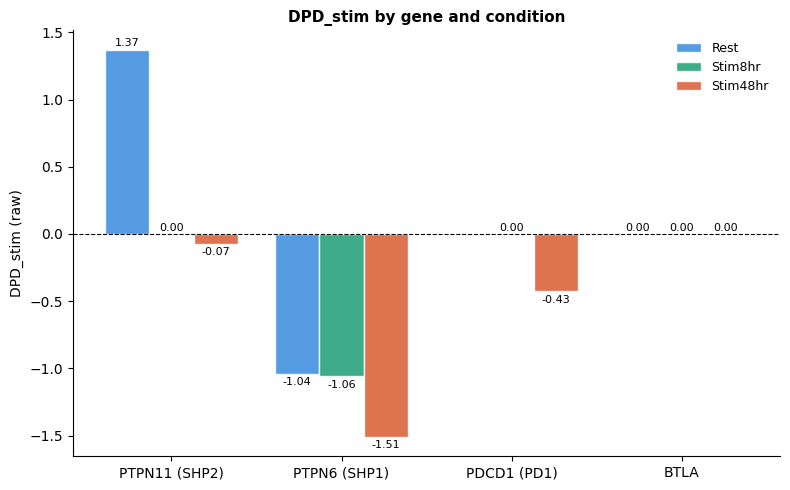

Saved: ../Results/diagnostics/plot_DPD_stim_bar.png


In [24]:
import matplotlib.pyplot as plt
import numpy as np

cond_colors = {"Rest": "#378ADD", "Stim8hr": "#1D9E75", "Stim48hr": "#D85A30"}
gene_order = [GENE_LABELS[g] for g in GENES_OF_INTEREST]
x = np.arange(len(gene_order))
width = 0.26
offsets = {"Rest": -width, "Stim8hr": 0, "Stim48hr": width}

fig, ax = plt.subplots(figsize=(8, 5))
for cond in ALL_CONDITIONS:
    vals = []
    for g in gene_order:
        v = dpd_long[(dpd_long["gene_label"]==g) & (dpd_long["condition"]==cond)]
        vals.append(float(v["DPD_stim"].values[0]) if len(v)>0 and pd.notna(v["DPD_stim"].values[0]) else float("nan"))
    bars = ax.bar(x + offsets[cond], vals, width, label=cond,
                  color=cond_colors[cond], alpha=0.85, edgecolor="white")
    for bar, val in zip(bars, vals):
        if not np.isnan(val):
            yoff = 0.01 if val >= 0 else -0.1
            ax.text(bar.get_x()+bar.get_width()/2, val+yoff,
                    f"{val:.2f}", ha="center", va="bottom", fontsize=8)
ax.axhline(0, color="black", lw=0.8, ls="--")
ax.set_xticks(x)
ax.set_xticklabels(gene_order, fontsize=10)
ax.set_ylabel("DPD_stim (raw)", fontsize=10)
ax.set_title("DPD_stim by gene and condition", fontsize=11, fontweight="bold")
ax.legend(frameon=False, fontsize=9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
fname = os.path.join(OUT_DIR, "plot_DPD_stim_bar.png")
plt.savefig(fname, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {fname}")

### 6.11 Plot: DPD_stim_norm by condition

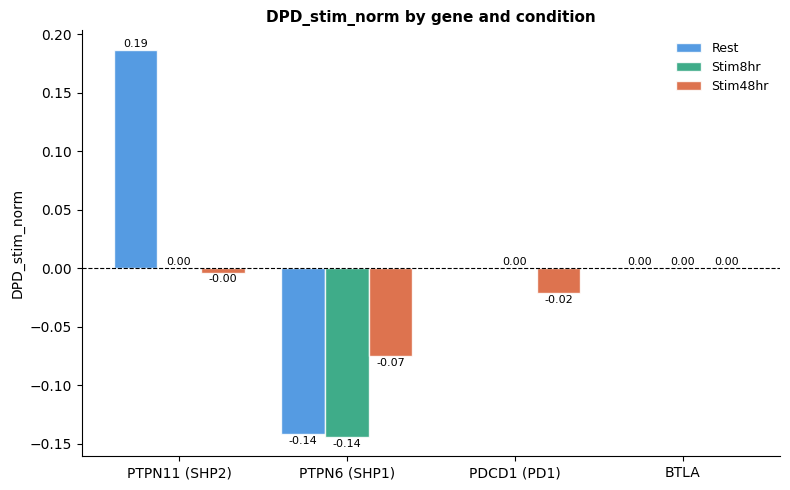

Saved: ../Results/diagnostics/plot_DPD_stim_norm_bar.png


In [25]:
import matplotlib.pyplot as plt
import numpy as np

cond_colors = {"Rest": "#378ADD", "Stim8hr": "#1D9E75", "Stim48hr": "#D85A30"}
gene_order = [GENE_LABELS[g] for g in GENES_OF_INTEREST]
x = np.arange(len(gene_order))
width = 0.26
offsets = {"Rest": -width, "Stim8hr": 0, "Stim48hr": width}

fig, ax = plt.subplots(figsize=(8, 5))
for cond in ALL_CONDITIONS:
    vals = []
    for g in gene_order:
        v = dpd_long[(dpd_long["gene_label"]==g) & (dpd_long["condition"]==cond)]
        vals.append(float(v["DPD_stim_norm"].values[0]) if len(v)>0 and pd.notna(v["DPD_stim_norm"].values[0]) else float("nan"))
    bars = ax.bar(x + offsets[cond], vals, width, label=cond,
                  color=cond_colors[cond], alpha=0.85, edgecolor="white")
    for bar, val in zip(bars, vals):
        if not np.isnan(val):
            yoff = 0.001 if val >= 0 else -0.01
            ax.text(bar.get_x()+bar.get_width()/2, val+yoff,
                    f"{val:.2f}", ha="center", va="bottom", fontsize=8)
ax.axhline(0, color="black", lw=0.8, ls="--")
ax.set_xticks(x)
ax.set_xticklabels(gene_order, fontsize=10)
ax.set_ylabel("DPD_stim_norm", fontsize=10)
ax.set_title("DPD_stim_norm by gene and condition", fontsize=11, fontweight="bold")
ax.legend(frameon=False, fontsize=9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
fname = os.path.join(OUT_DIR, "plot_DPD_stim_norm_bar.png")
plt.savefig(fname, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {fname}")

### 6.12 Plot: DPD_btla (raw) by condition

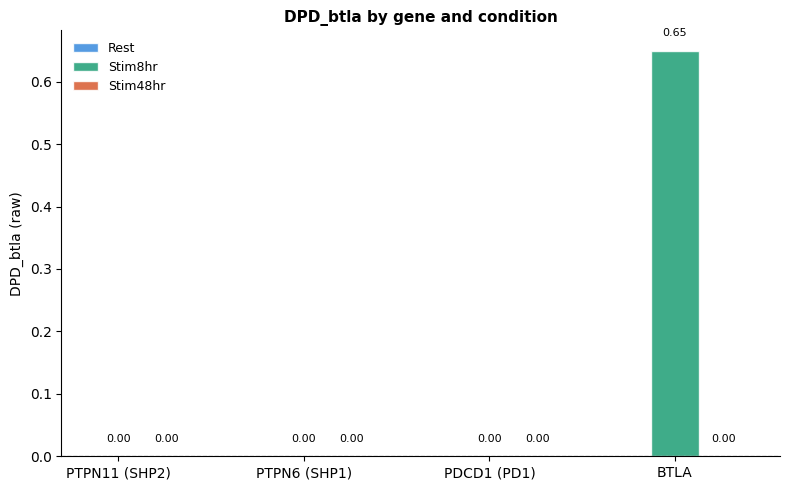

Saved: ../Results/diagnostics/plot_DPD_btla_bar.png


In [17]:
import matplotlib.pyplot as plt
import numpy as np

cond_colors = {"Rest": "#378ADD", "Stim8hr": "#1D9E75", "Stim48hr": "#D85A30"}
gene_order = [GENE_LABELS[g] for g in GENES_OF_INTEREST]
x = np.arange(len(gene_order))
width = 0.26
offsets = {"Rest": -width, "Stim8hr": 0, "Stim48hr": width}

fig, ax = plt.subplots(figsize=(8, 5))
for cond in ALL_CONDITIONS:
    vals = []
    for g in gene_order:
        v = dpd_long[(dpd_long["gene_label"]==g) & (dpd_long["condition"]==cond)]
        vals.append(float(v["DPD_btla"].values[0]) if len(v)>0 and pd.notna(v["DPD_btla"].values[0]) else float("nan"))
    bars = ax.bar(x + offsets[cond], vals, width, label=cond,
                  color=cond_colors[cond], alpha=0.85, edgecolor="white")
    for bar, val in zip(bars, vals):
        if not np.isnan(val):
            yoff = 0.02 if val >= 0 else -0.2
            ax.text(bar.get_x()+bar.get_width()/2, val+yoff,
                    f"{val:.2f}", ha="center", va="bottom", fontsize=8)
ax.axhline(0, color="black", lw=0.8, ls="--")
ax.set_xticks(x)
ax.set_xticklabels(gene_order, fontsize=10)
ax.set_ylabel("DPD_btla (raw)", fontsize=10)
ax.set_title("DPD_btla by gene and condition", fontsize=11, fontweight="bold")
ax.legend(frameon=False, fontsize=9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
fname = os.path.join(OUT_DIR, "plot_DPD_btla_bar.png")
plt.savefig(fname, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {fname}")

### 6.13 Plot: DPD_btla_norm by condition

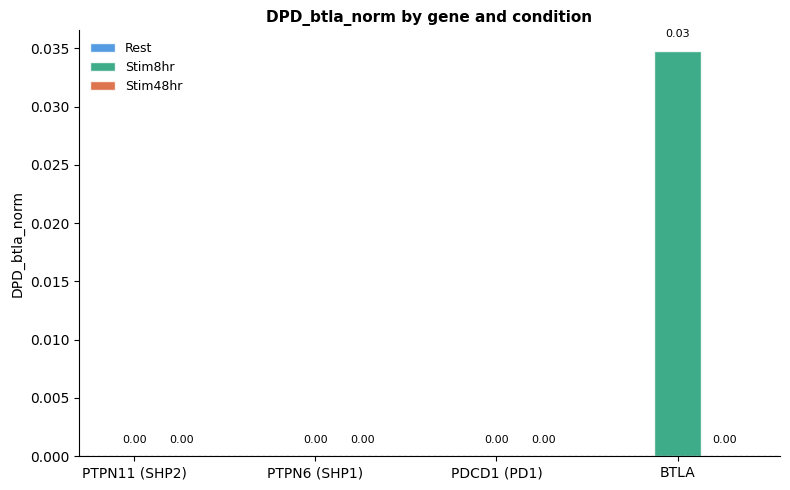

Saved: ../Results/diagnostics/plot_DPD_btla_norm_bar.png


In [18]:
import matplotlib.pyplot as plt
import numpy as np

cond_colors = {"Rest": "#378ADD", "Stim8hr": "#1D9E75", "Stim48hr": "#D85A30"}
gene_order = [GENE_LABELS[g] for g in GENES_OF_INTEREST]
x = np.arange(len(gene_order))
width = 0.26
offsets = {"Rest": -width, "Stim8hr": 0, "Stim48hr": width}

fig, ax = plt.subplots(figsize=(8, 5))
for cond in ALL_CONDITIONS:
    vals = []
    for g in gene_order:
        v = dpd_long[(dpd_long["gene_label"]==g) & (dpd_long["condition"]==cond)]
        vals.append(float(v["DPD_btla_norm"].values[0]) if len(v)>0 and pd.notna(v["DPD_btla_norm"].values[0]) else float("nan"))
    bars = ax.bar(x + offsets[cond], vals, width, label=cond,
                  color=cond_colors[cond], alpha=0.85, edgecolor="white")
    for bar, val in zip(bars, vals):
        if not np.isnan(val):
            yoff = 0.001 if val >= 0 else -0.1
            ax.text(bar.get_x()+bar.get_width()/2, val+yoff,
                    f"{val:.2f}", ha="center", va="bottom", fontsize=8)
ax.axhline(0, color="black", lw=0.8, ls="--")
ax.set_xticks(x)
ax.set_xticklabels(gene_order, fontsize=10)
ax.set_ylabel("DPD_btla_norm", fontsize=10)
ax.set_title("DPD_btla_norm by gene and condition", fontsize=11, fontweight="bold")
ax.legend(frameon=False, fontsize=9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
fname = os.path.join(OUT_DIR, "plot_DPD_btla_norm_bar.png")
plt.savefig(fname, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {fname}")

### 6.14 Plot: Delta DPD_stim (raw) vs Rest

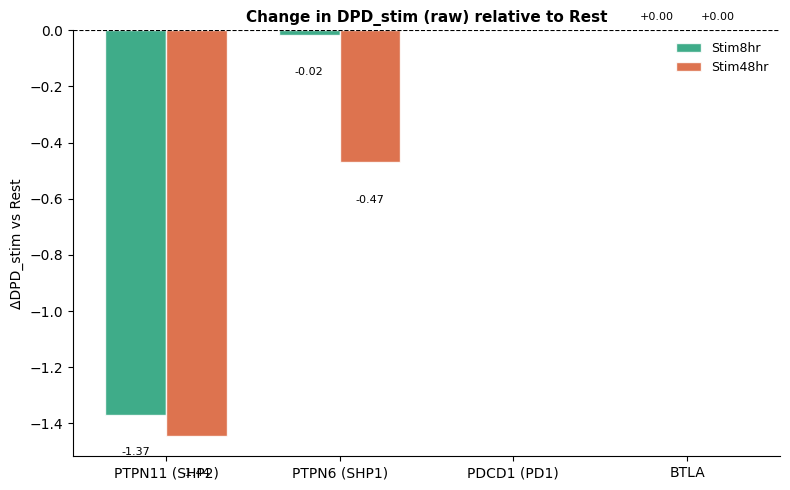

Saved: ../Results/diagnostics/plot_delta_stim_delta_bar.png


In [19]:
import matplotlib.pyplot as plt
import numpy as np

cond_colors = {"Stim8hr": "#1D9E75", "Stim48hr": "#D85A30"}
gene_order = [GENE_LABELS[g] for g in GENES_OF_INTEREST]
stim_conds = ["Stim8hr", "Stim48hr"]
x = np.arange(len(gene_order))
width = 0.35
offsets = {"Stim8hr": -width/2, "Stim48hr": width/2}

fig, ax = plt.subplots(figsize=(8, 5))
for cond in stim_conds:
    vals = []
    for g in gene_order:
        v = dpd_long[(dpd_long["gene_label"]==g) & (dpd_long["condition"]==cond)]
        vals.append(float(v["delta_stim"].values[0]) if len(v)>0 and pd.notna(v["delta_stim"].values[0]) else float("nan"))
    bars = ax.bar(x + offsets[cond], vals, width, label=cond,
                  color=cond_colors[cond], alpha=0.85, edgecolor="white")
    for bar, val in zip(bars, vals):
        if not np.isnan(val):
            yoff = 0.03 if val >= 0 else -0.15
            ax.text(bar.get_x()+bar.get_width()/2, val+yoff,
                    f"{val:+.2f}", ha="center", va="bottom", fontsize=8)
ax.axhline(0, color="black", lw=0.8, ls="--")
ax.set_xticks(x)
ax.set_xticklabels(gene_order, fontsize=10)
ax.set_ylabel("ΔDPD_stim vs Rest", fontsize=10)
ax.set_title("Change in DPD_stim (raw) relative to Rest", fontsize=11, fontweight="bold")
ax.legend(frameon=False, fontsize=9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
fname = os.path.join(OUT_DIR, "plot_delta_stim_delta_bar.png")
plt.savefig(fname, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {fname}")

### 6.15 Plot: Delta DPD_stim_norm vs Rest

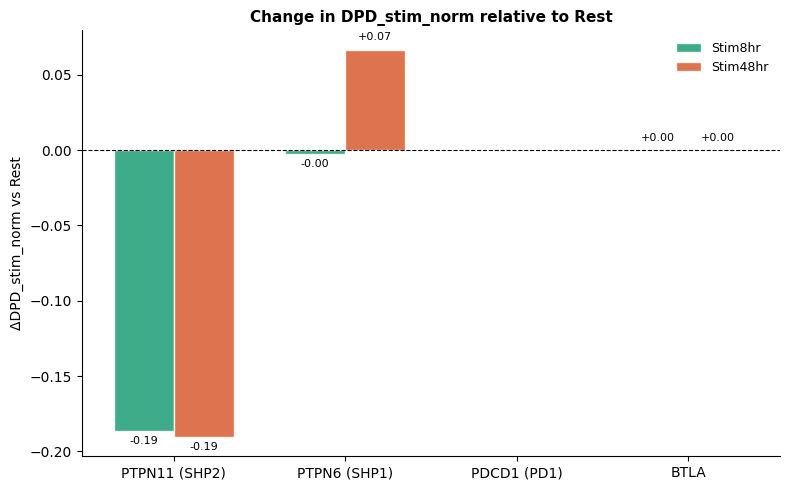

Saved: ../Results/diagnostics/plot_delta_stim_norm_delta_bar.png


In [27]:
import matplotlib.pyplot as plt
import numpy as np

cond_colors = {"Stim8hr": "#1D9E75", "Stim48hr": "#D85A30"}
gene_order = [GENE_LABELS[g] for g in GENES_OF_INTEREST]
stim_conds = ["Stim8hr", "Stim48hr"]
x = np.arange(len(gene_order))
width = 0.35
offsets = {"Stim8hr": -width/2, "Stim48hr": width/2}

fig, ax = plt.subplots(figsize=(8, 5))
for cond in stim_conds:
    vals = []
    for g in gene_order:
        v = dpd_long[(dpd_long["gene_label"]==g) & (dpd_long["condition"]==cond)]
        vals.append(float(v["delta_stim_norm"].values[0]) if len(v)>0 and pd.notna(v["delta_stim_norm"].values[0]) else float("nan"))
    bars = ax.bar(x + offsets[cond], vals, width, label=cond,
                  color=cond_colors[cond], alpha=0.85, edgecolor="white")
    for bar, val in zip(bars, vals):
        if not np.isnan(val):
            yoff = 0.005 if val >= 0 else -0.01
            ax.text(bar.get_x()+bar.get_width()/2, val+yoff,
                    f"{val:+.2f}", ha="center", va="bottom", fontsize=8)
ax.axhline(0, color="black", lw=0.8, ls="--")
ax.set_xticks(x)
ax.set_xticklabels(gene_order, fontsize=10)
ax.set_ylabel("ΔDPD_stim_norm vs Rest", fontsize=10)
ax.set_title("Change in DPD_stim_norm relative to Rest", fontsize=11, fontweight="bold")
ax.legend(frameon=False, fontsize=9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
fname = os.path.join(OUT_DIR, "plot_delta_stim_norm_delta_bar.png")
plt.savefig(fname, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {fname}")

### 6.16 Plot: DPD_stim_norm trajectory

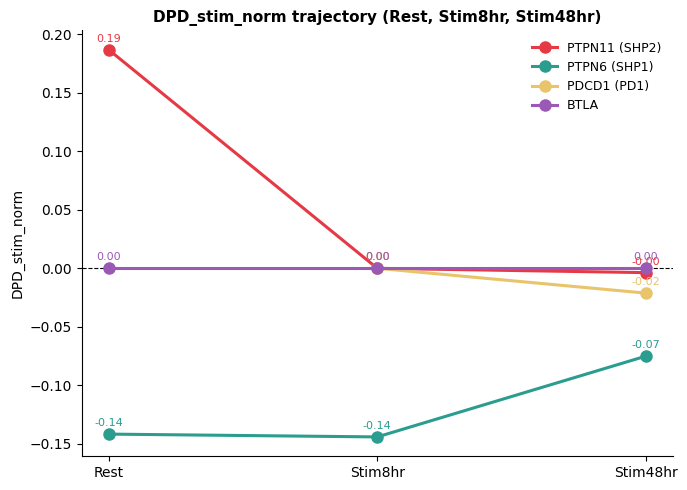

Saved: ../Results/diagnostics/plot_DPD_stim_norm_trajectory.png


In [21]:
import matplotlib.pyplot as plt
import numpy as np

gene_colors = ["#E63946", "#2A9D8F", "#E9C46A", "#9B59B6"]
gene_order = [GENE_LABELS[g] for g in GENES_OF_INTEREST]
cond_x = {"Rest": 0, "Stim8hr": 1, "Stim48hr": 2}

fig, ax = plt.subplots(figsize=(7, 5))
for gi, (gene, glabel) in enumerate(zip(GENES_OF_INTEREST, gene_order)):
    gdata = dpd_long[dpd_long["gene"]==gene].sort_values("condition")
    xs, ys = [], []
    for _, row in gdata.iterrows():
        if pd.notna(row["DPD_stim_norm"]):
            xs.append(cond_x[row["condition"]])
            ys.append(float(row["DPD_stim_norm"]))
    ax.plot(xs, ys, marker="o", linewidth=2.2, markersize=8,
            color=gene_colors[gi], label=glabel, zorder=3)
    for xi, yi in zip(xs, ys):
        ax.text(xi, yi+0.005, f"{yi:.2f}", ha="center", va="bottom",
                fontsize=8, color=gene_colors[gi])
ax.axhline(0, color="black", lw=0.8, ls="--", zorder=1)
ax.set_xticks([0, 1, 2])
ax.set_xticklabels(["Rest", "Stim8hr", "Stim48hr"], fontsize=10)
ax.set_ylabel("DPD_stim_norm", fontsize=10)
ax.set_title("DPD_stim_norm trajectory (Rest, Stim8hr, Stim48hr)", fontsize=11, fontweight="bold")
ax.legend(frameon=False, fontsize=9, loc="best")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
fname = os.path.join(OUT_DIR, "plot_DPD_stim_norm_trajectory.png")
plt.savefig(fname, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {fname}")

### 6.17 Plot: DPD_stim (raw) trajectory

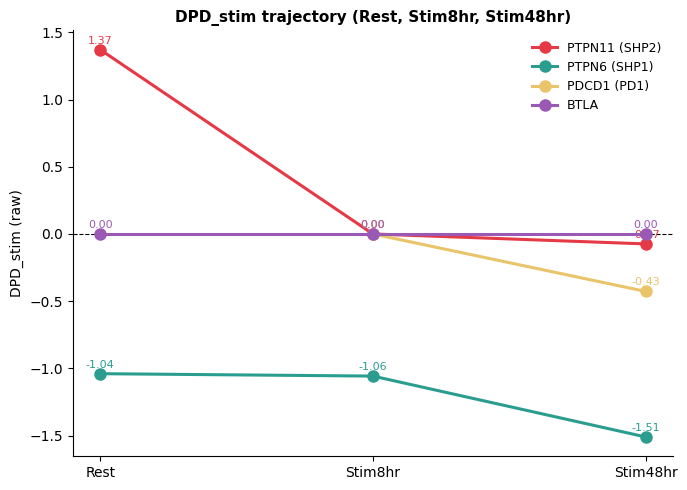

Saved: ../Results/diagnostics/plot_DPD_stim_trajectory.png


In [22]:
import matplotlib.pyplot as plt
import numpy as np

gene_colors = ["#E63946", "#2A9D8F", "#E9C46A", "#9B59B6"]
gene_order = [GENE_LABELS[g] for g in GENES_OF_INTEREST]
cond_x = {"Rest": 0, "Stim8hr": 1, "Stim48hr": 2}

fig, ax = plt.subplots(figsize=(7, 5))
for gi, (gene, glabel) in enumerate(zip(GENES_OF_INTEREST, gene_order)):
    gdata = dpd_long[dpd_long["gene"]==gene].sort_values("condition")
    xs, ys = [], []
    for _, row in gdata.iterrows():
        if pd.notna(row["DPD_stim"]):
            xs.append(cond_x[row["condition"]])
            ys.append(float(row["DPD_stim"]))
    ax.plot(xs, ys, marker="o", linewidth=2.2, markersize=8,
            color=gene_colors[gi], label=glabel, zorder=3)
    for xi, yi in zip(xs, ys):
        ax.text(xi, yi+0.03, f"{yi:.2f}", ha="center", va="bottom",
                fontsize=8, color=gene_colors[gi])
ax.axhline(0, color="black", lw=0.8, ls="--", zorder=1)
ax.set_xticks([0, 1, 2])
ax.set_xticklabels(["Rest", "Stim8hr", "Stim48hr"], fontsize=10)
ax.set_ylabel("DPD_stim (raw)", fontsize=10)
ax.set_title("DPD_stim trajectory (Rest, Stim8hr, Stim48hr)", fontsize=11, fontweight="bold")
ax.legend(frameon=False, fontsize=9, loc="best")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
fname = os.path.join(OUT_DIR, "plot_DPD_stim_trajectory.png")
plt.savefig(fname, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {fname}")

### 6.18 Save consolidated Excel

In [23]:
fname_xlsx = os.path.join(OUT_DIR, "DPD_summary_checkpoint_genes.xlsx")
gene_order_labels = [GENE_LABELS[g] for g in GENES_OF_INTEREST]
sheets = {"DPD_stim_raw": "DPD_stim",
    "DPD_stim_norm": "DPD_stim_norm",
    "DPD_btla_raw": "DPD_btla",
    "DPD_btla_norm": "DPD_btla_norm",
    "delta_stim_raw": "delta_stim",
    "delta_stim_norm": "delta_stim_norm",
    "rank_pct": "rank_pct",
    "n_sig_genes": "n_sig_genes"}
with pd.ExcelWriter(fname_xlsx) as writer:
    for sheet, col in sheets.items():
        p = dpd_long.pivot(index="gene_label", columns="condition", values=col)
        p = p.reindex(gene_order_labels)
        p.to_excel(writer, sheet_name=sheet)
    dpd_long.to_excel(writer, sheet_name="full_table", index=False)
print(f"Saved: {fname_xlsx}")

Saved: ../Results/diagnostics/DPD_summary_checkpoint_genes.xlsx
